# Data Collection & Indicator calucation

In [1]:
import warnings

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
import pandas as pd
import numpy as np

data = pd.read_csv("/Users/sonlamtong/Desktop/Python/Thesis/Technical Analysis /Data Set/aapl_Training_Data.csv")
data = data.set_index("Date")

training_data = data.loc[:, ~data.columns.isin(["target"])].copy()
target= data.loc[:, ["target"]].copy()

data.head()
display(training_data.shape, target.shape)

(2229, 93)

(2229, 1)

## Scoring for Tuning and Optimization:

In [3]:
scoring = "f1"

## Data Preparation:

In [4]:
from sklearn.preprocessing import StandardScaler

rule_based_indicators =[]
for col in data.columns:
    if len(pd.unique(data.loc[:, col])) <= 2:
        rule_based_indicators.append(col)

data_1= training_data.copy()
result= target.copy()

scaler = StandardScaler()
data_1.loc[:, ~data_1.columns.isin(rule_based_indicators)] = scaler.fit_transform(data_1.loc[:, ~data_1.columns.isin(rule_based_indicators)].copy(), result)

train_test_count = round(len(data_1)*0.2)

X= data_1.iloc[:-train_test_count]
y= result[:-train_test_count].copy()

Valid_set = data_1.iloc[-train_test_count:]
Valid_result = result[-train_test_count:].copy()

X.head()

,close,high,low,open,volume,return,log_return,volume_adi,volume_obv,volume_cmf,...,momentum_ppo,momentum_ppo_signal,momentum_ppo_hist,momentum_pvo,momentum_pvo_signal,momentum_pvo_hist,momentum_kama,others_dr,others_dlr,others_cr
Date,,,,,,,,,,,,,,,,,,,,,
2015-10-13,-1.145781,-1.146796,-1.146079,-1.148704,0.592432,-0.016935,0.036976,-1.882192,-1.424890,0.827169,...,-1.456929,-1.066068,-1.535830,3.304726,2.576374,2.300309,-1.135181,0.328649,0.372321,-1.145422
2015-10-14,-1.150721,-1.149676,-1.149620,-1.147233,1.431972,-0.177462,-0.759405,-1.871643,-1.366883,0.530250,...,-1.652183,-1.202157,-1.763602,3.280920,2.896613,1.807574,-1.135632,-0.000635,0.009920,-1.144828
2015-10-15,-1.145562,-1.147880,-1.146680,-1.148359,0.932585,0.115472,0.694599,-1.890440,-1.444922,1.108847,...,-1.602349,-1.300489,-1.274918,3.132394,3.114933,1.234610,-1.136074,-1.016760,-1.125280,-1.149769
2015-10-16,-1.148126,-1.148190,-1.146554,-1.145699,1.047271,-0.108539,-0.415750,-1.857243,-1.378798,0.919745,...,-1.445269,-1.345931,-0.590399,2.835261,3.213829,0.563225,-1.136219,-0.237359,-0.252247,-1.144609
2015-10-19,-1.145969,-1.148964,-1.147882,-1.148766,0.350414,0.028406,0.261523,-1.872321,-1.447658,0.862559,...,-1.296892,-1.350902,-0.066603,2.186255,3.127467,-0.478262,-1.136397,0.649241,0.722647,-1.147174


# LMST support functions:

In [5]:
import torch

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

## Feature Selection:

In [6]:
selected_features = X.columns.copy()

## Train

In [7]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# LSTM Model Definition
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        if dropout == False:
            super(LSTMModel, self).__init__()
            self.lstm = nn.LSTM(input_size=input_size,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                batch_first=True)
            self.relu = nn.ReLU()  # Add ReLU activation
            self.dropout = nn.Dropout(0.3)
            self.fc1 = nn.Linear(hidden_size, 32)
            self.fc2 = nn.Linear(32, 1)
        else:
            super(LSTMModel, self).__init__()
            self.lstm = nn.LSTM(input_size=input_size,
                                hidden_size=hidden_size,
                                num_layers=num_layers,
                                dropout=dropout if num_layers > 1 else 0,
                                batch_first=True)
            self.fc = nn.Linear(hidden_size, 1)
            self.sigmoid = nn.Sigmoid()
            self.dropout = dropout

    def forward(self, x):
        if self.dropout == False:
            out, _ = self.lstm(x)
            out = out[:, -1, :]  # Get the last time step
            out = self.dropout(out)
            out = self.relu(self.fc1(out))
            out = self.fc2(out)
            return out
        else:
            out, _ = self.lstm(x)
            out = out[:, -1, :]  # Take last timestep
            out = self.fc(out)
            return self.sigmoid(out)

def create_sequences(X, y, seq_len):
    X_seq, y_seq = [], []
    for i in range(len(X) - seq_len):
        X_seq.append(X[i:i+seq_len])
        y_seq.append(y[i+seq_len])
    return np.array(X_seq), np.array(y_seq)

# Training Function
def LSTM__training(X_train, y_train, hidden_size=64, num_epochs=20, lr=1e-3, num_layers=1, dropout=False, batch_size=64, sequence_length=1):
    
    X_train, y_train = create_sequences(X_train, y_train, seq_len=sequence_length)
    
    # Convert to PyTorch tensors
    X_train = torch.tensor(X_train, dtype=torch.float32)
    y_train = torch.tensor(y_train, dtype=torch.float32)

    # Ensure X has 3D shape [batch, seq_len, features]
    if X_train.ndim == 2:
        X_train = X_train[:, None, :]  # add seq_len=1 dimension
    X_train, y_train = X_train.to(device), y_train.to(device)

    # Define model
    input_size = X_train.shape[2]
    model = LSTMModel(input_size=input_size, hidden_size=hidden_size, num_layers=num_layers, dropout=dropout).to(device)
    
    '''
    # Compute class imbalance for BCEWithLogitsLoss
    num_pos = (y_train == 1).sum().item()
    num_neg = (y_train == 0).sum().item()

    if num_pos == 0:  # Avoid divide-by-zero
        pos_weight = torch.tensor(1.0, dtype=torch.float32).to(device)
    else:
        pos_weight = torch.tensor(num_neg / num_pos, dtype=torch.float32).to(device)

    # Define loss and optimizer
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    '''

    criterion = nn.BCELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    
    train_dataset = TensorDataset(X_train, y_train)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    # Training loop
    model.train()
    if dropout == False:
        for epoch in range(num_epochs):
            for xb, yb in train_loader:
                optimizer.zero_grad()
                outputs = model(xb).squeeze()
                loss = criterion(outputs, yb)
                loss.backward()
                optimizer.step()
    else:
        for epoch in range(5):  # Keep it short for BO
            for i in range(0, len(X_train), batch_size):
                xb = torch.tensor(X_train[i:i+batch_size]).to(device)
                yb = torch.tensor(y_train[i:i+batch_size]).view(-1, 1).to(device)
                optimizer.zero_grad()
                preds = model(xb)
                loss = criterion(preds, yb)
                loss.backward()
                optimizer.step()
        '''
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {loss.item():.4f}")
        '''

    return model

## Hyperparameter Tuning:

In [8]:
import torch
import torch.nn as nn
import numpy as np
from bayes_opt import BayesianOptimization
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score

def hyperparams_tuning(X_train_1, y_train_1):
    def train_model(hidden_size, num_layers, dropout, lr, batch_size, sequence_length):
        hidden_size = int(hidden_size)
        num_layers = int(num_layers)
        batch_size = int(batch_size)
        sequence_length = int(sequence_length)

        kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X_train_1, y_train_1):
            X_train, X_val = X_train_1.iloc[train_idx, :], X_train_1.iloc[val_idx, :]
            y_train, y_val = y_train_1.iloc[train_idx, :], y_train_1.iloc[val_idx, :]

            model = LSTM__training(X_train.to_numpy(), y_train.to_numpy(), hidden_size=hidden_size, lr=lr, num_layers=num_layers, dropout=dropout, batch_size=batch_size, sequence_length=sequence_length).to(device)
            
            X_val, y_val = create_sequences(X_val.to_numpy(), y_val.to_numpy(), seq_len=sequence_length)
            X_val, y_val = torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.float32)
            # Ensure X has 3D shape [batch, seq_len, features]
            if X_val.ndim == 2:
                X_val = X_val[:, None, :]  # add seq_len=1 dimension
            X_val, y_val = X_val.to(device), y_val.to(device)

            # Evaluate
            model.eval()
            val_preds = []
            with torch.no_grad():
                for i in range(0, len(X_val), batch_size):
                    xb = torch.tensor(X_val[i:i+batch_size]).to(device)
                    preds = model(xb).detach().cpu().numpy().flatten()
                    val_preds.extend(preds)
                val_preds = (np.array(val_preds) > 0.5).astype(int)
                y_val_trimmed = y_val.detach().cpu().numpy().flatten()
                score = f1_score(y_val_trimmed, val_preds)

        return score.mean()

    # Define the BO space
    pbounds = {
        'hidden_size': (32, 256),
        'num_layers': (1, 3),
        'dropout': (0.0, 0.5),
        'lr': (1e-4, 1e-2),
        'batch_size': (32, 128),
        'sequence_length': (10, 50)
    }

    # Run Bayesian Optimization
    optimizer = BayesianOptimization(
        f=train_model,
        pbounds=pbounds,
        verbose=2,
        random_state=42
    )

    optimizer.maximize(init_points=5, n_iter=15)

    print("\n🔍 Best Parameters:")
    print(optimizer.max)
    return optimizer.max['params']

## Threshold tuning

In [9]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import precision_recall_curve
import numpy as np

def Threshold_tuning(model, y_train_1, X_train_1, seq_len, batch_size):
    kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    y_true_all = []
    y_proba_all = []

    for train_idx, val_idx in kf.split(X_train_1, y_train_1):
        X_train, X_val = X_train_1.iloc[train_idx, :], X_train_1.iloc[val_idx, :]
        y_train, y_val = y_train_1.iloc[train_idx, :], y_train_1.iloc[val_idx, :]
        
        ### test set for threshold identify:
        X_val, y_val = create_sequences(X_val.to_numpy(), y_val.to_numpy(), seq_len)
        X_val = torch.tensor(X_val, dtype=torch.float32)  # X_test must be a 3D array
        y_val = torch.tensor(y_val, dtype=torch.float32)
        if X_val.ndim == 2:
            X_val = X_val[:, None, :]  # add seq_len=1 dimension
        X_val = X_val.to(device)
        y_val = y_val.to(device)
        
        val_preds = []
        # Evaluate
        model.eval()
        val_preds = []
        with torch.no_grad():
            for i in range(0, len(X_val), batch_size):
                xb = torch.tensor(X_val[i:i+batch_size]).to(device)
                preds = model(xb).detach().cpu().numpy().flatten()
                val_preds.extend(preds)
                #val_preds = (np.array(val_preds) > 0.5).astype(int)
            
            y_val_trimmed = y_val.detach().cpu().numpy().flatten()
            

            # Store true and predicted values
            y_true_all.extend(y_val_trimmed)
            y_proba_all.extend(val_preds)

    # Convert to numpy arrays
    y_true_all = np.array(y_true_all)
    y_proba_all = np.array(y_proba_all)

    # Compute precision-recall curve
    precision, recall, thresholds = precision_recall_curve(y_true_all, y_proba_all)

    # Compute F1 scores for each threshold
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)

    # Get best threshold
    best_threshold = thresholds[np.argmax(f1_scores)]

    print(f"Best threshold from 5-fold CV: {best_threshold}")
    return best_threshold

# LSTM model ACTIVE:

## Model Params_Tuning:

In [10]:
X_train_1 = X.loc[:, selected_features].copy()
y_train_1 = y.copy()

best_params = hyperparams_tuning(X_train_1, y_train_1)

|   iter    |  target   | batch_... |  dropout  | hidden... |    lr     | num_la... | sequen... |
-------------------------------------------------------------------------------------------------
| 1         | 0.5813    | 67.96     | 0.4754    | 196.0     | 0.006027  | 1.312     | 16.24     |
| 2         | 0.6       | 37.58     | 0.4331    | 166.6     | 0.00711   | 1.041     | 48.8      |
| 3         | 0.6071    | 111.9     | 0.1062    | 72.73     | 0.001916  | 1.608     | 30.99     |
| 4         | 0.5676    | 73.47     | 0.1456    | 169.1     | 0.001481  | 1.584     | 24.65     |
| 5         | 0.6384    | 75.78     | 0.3926    | 76.73     | 0.005191  | 2.185     | 11.86     |
| 6         | 0.6098    | 53.6      | 0.1944    | 57.02     | 0.00123   | 2.654     | 11.66     |
| 7         | 0.6284    | 77.62     | 0.2755    | 78.06     | 0.001891  | 1.657     | 11.18     |
| 8         | 0.5942    | 74.02     | 0.2674    | 69.16     | 0.003692  | 2.159     | 13.66     |
| 9         | 0.6545

## Model Defined through training fucntion:

In [11]:
best_params['X_train'] = X.loc[:, selected_features].copy().to_numpy()
best_params['y_train'] = y.copy().to_numpy().T[0]
'''
best_params['X_train'] = X.loc[:, selected_features].copy()
best_params['y_train'] = y.copy()
'''

for param in ["hidden_size", "num_layers", "batch_size", "sequence_length"]:
    best_params[param] = int(best_params[param])

In [12]:
model = LSTM__training(**best_params)

## Threshold Tuning Result:

In [13]:
X_train_1 = X.loc[:, selected_features].copy().reset_index(drop=True)
y_train_1 = y.copy().reset_index(drop=True)
best_threshold = Threshold_tuning(model=model, X_train_1=X_train_1, y_train_1=y_train_1, seq_len=best_params['sequence_length'], batch_size=best_params['batch_size'])

Best threshold from 5-fold CV: 0.2495969533920288


## Forcasting:

In [14]:
X_test = Valid_set.loc[:, selected_features].copy().to_numpy()
y_test = Valid_result.copy().T.to_numpy()[0]

X_test, y_test = create_sequences(X_test, y_test, seq_len=best_params['sequence_length'])
# Convert to PyTorch tensors FIRST before sending to MPS
X_test = torch.tensor(X_test, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
if X_test.ndim == 2:
    X_test = X_test[:, None, :]
# Now move tensors to   
X_test = X_test.to(device)
y_test = y_test.to(device)

# Evaluate
batch_size=best_params['batch_size']
model.eval()
val_preds = []
with torch.no_grad():
    for i in range(0, len(X_test), batch_size):
        xb = torch.tensor(X_test[i:i+batch_size]).to(device)
        preds = model(xb).detach().cpu().numpy().flatten()
        val_preds.extend(preds)
    y_val_trimmed = y_test.detach().cpu().numpy().flatten()

y_pred_prob = np.array(val_preds.copy())

# y_test back to CPU for metrics
y_true = y_val_trimmed
"""
"""
best_threshold = (y_pred_prob.min() + y_pred_prob.max())/2
y_pred = (y_pred_prob >= best_threshold).astype(int)

# Diagnosis:

### Proba Check:

[0 1]


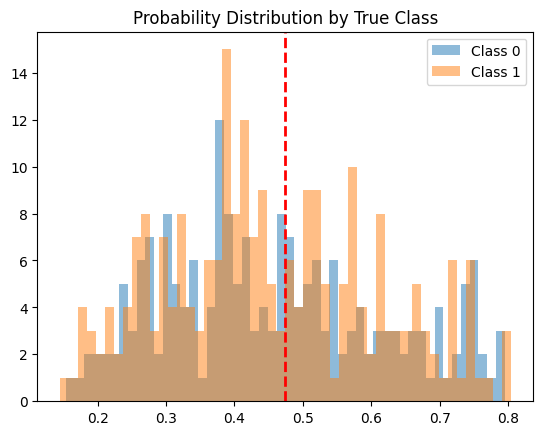

In [15]:
from matplotlib import pyplot as plt

print(np.unique(y_pred))

plt.hist(y_pred_prob[y_true==0], bins=50, alpha=0.5, label='Class 0')
plt.hist(y_pred_prob[y_true==1], bins=50, alpha=0.5, label='Class 1')
plt.axvline(x= best_threshold, linestyle="--", linewidth=2, color="red")
plt.legend()
plt.title(f"Probability Distribution by True Class")
plt.show()

In [16]:
print("Feature stats:\n", X.describe())

Feature stats:
              close         high          low         open       volume  \
count  1783.000000  1783.000000  1783.000000  1783.000000  1783.000000   
mean     -0.344355    -0.344031    -0.344628    -0.344280     0.199930   
std       0.794637     0.795427     0.794138     0.794815     0.994342   
min      -1.208355    -1.206621    -1.208644    -1.209399    -1.260142   
25%      -0.998657    -1.000071    -0.997337    -0.998137    -0.453316   
50%      -0.808669    -0.810136    -0.808569    -0.810346    -0.035296   
75%       0.499655     0.500913     0.500339     0.497607     0.572361   
max       1.207490     1.205744     1.220956     1.207557     7.971937   

            return   log_return   volume_adi   volume_obv   volume_cmf  ...  \
count  1783.000000  1783.000000  1783.000000  1783.000000  1783.000000  ...   
mean      0.000242     0.006741    -0.310081    -0.279146    -0.015386  ...   
std       0.856190     1.028855     0.875594     0.917309     1.011825  ...   
m

## Validation:

In [17]:
import numpy as np
unique, counts = np.unique(y, return_counts=True)
print("Training label distribution:", dict(zip(unique, counts)))

Training label distribution: {0.0: 837, 1.0: 946}


In [18]:
import numpy as np
print("Test labels:", np.unique(y_true, return_counts=True))
print("Predictions:", np.unique(y_pred, return_counts=True))

Test labels: (array([0., 1.], dtype=float32), array([195, 237]))
Predictions: (array([0, 1]), array([247, 185]))


In [19]:
from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_true, y_pred))

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

Confusion Matrix:
[[111  84]
 [136 101]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.45      0.57      0.50       195
         1.0       0.55      0.43      0.48       237

    accuracy                           0.49       432
   macro avg       0.50      0.50      0.49       432
weighted avg       0.50      0.49      0.49       432



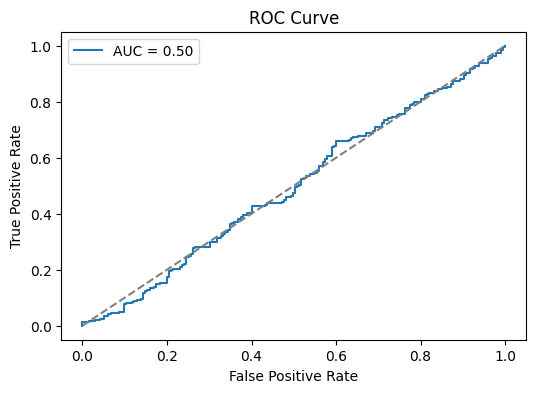

In [20]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()